In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Set seaborn style
sns.set(style='whitegrid')
# Color palette for vegetables
veg_colors = {
    'CARROT': 'orange',
    'PUMPKIN': 'green',
    'BRINJALS': 'purple',
    'BEETROOT': 'red'
}

## Step 1 — Data Preparation
- Filter to Meegoda and selected vegetables
- Create time_index
- Sort and drop null prices

In [2]:
# Load data
df = pd.read_csv('../main data set/main_data_cleaned.csv')

# Filter for Meegoda and selected vegetables
veg_list = ['CARROT', 'PUMPKIN', 'BRINJALS', 'BEETROOT']
df_meegoda = df[(df['location'] == 'Meegoda') & (df['vegetable_type'].isin(veg_list))].copy()

# Create time_index
df_meegoda['time_index'] = df_meegoda['year'] * 100 + df_meegoda['week_num']
# Sort
df_meegoda = df_meegoda.sort_values('time_index')
# Drop rows with null price
df_meegoda = df_meegoda.dropna(subset=['price'])
df_meegoda.reset_index(drop=True, inplace=True)
df_meegoda.head()

,Year_Week,year,location,code,vegetable_type,price,no_of_holidays,vegetable_zone,seasonality,lanka_auto_diesel_price,mean_apparent_temperature,rain_sum,usd_exchange_rate,week_num,time_index
0,2013-W01,2013,Meegoda,323,PUMPKIN,57.5,NaN,NaN,NaN,115.0,NaN,NaN,127.0721,1,201301
1,2013-W01,2013,Meegoda,305,BEETROOT,132.0,NaN,NaN,NaN,115.0,NaN,NaN,127.0721,1,201301
2,2013-W01,2013,Meegoda,321,BRINJALS,135.0,NaN,NaN,NaN,115.0,NaN,NaN,127.0721,1,201301
3,2013-W01,2013,Meegoda,303,CARROT,156.0,NaN,NaN,NaN,115.0,NaN,NaN,127.0721,1,201301
4,2013-W02,2013,Meegoda,323,PUMPKIN,55.0,NaN,NaN,NaN,115.0,NaN,NaN,126.3521,2,201302


## Step 2 — Dual-axis Line Chart (Meegoda, 4 vegetables vs diesel)
- Each subplot: vegetable price (left), diesel price (right)
- Save as plot1_dual_axis_meegoda.png

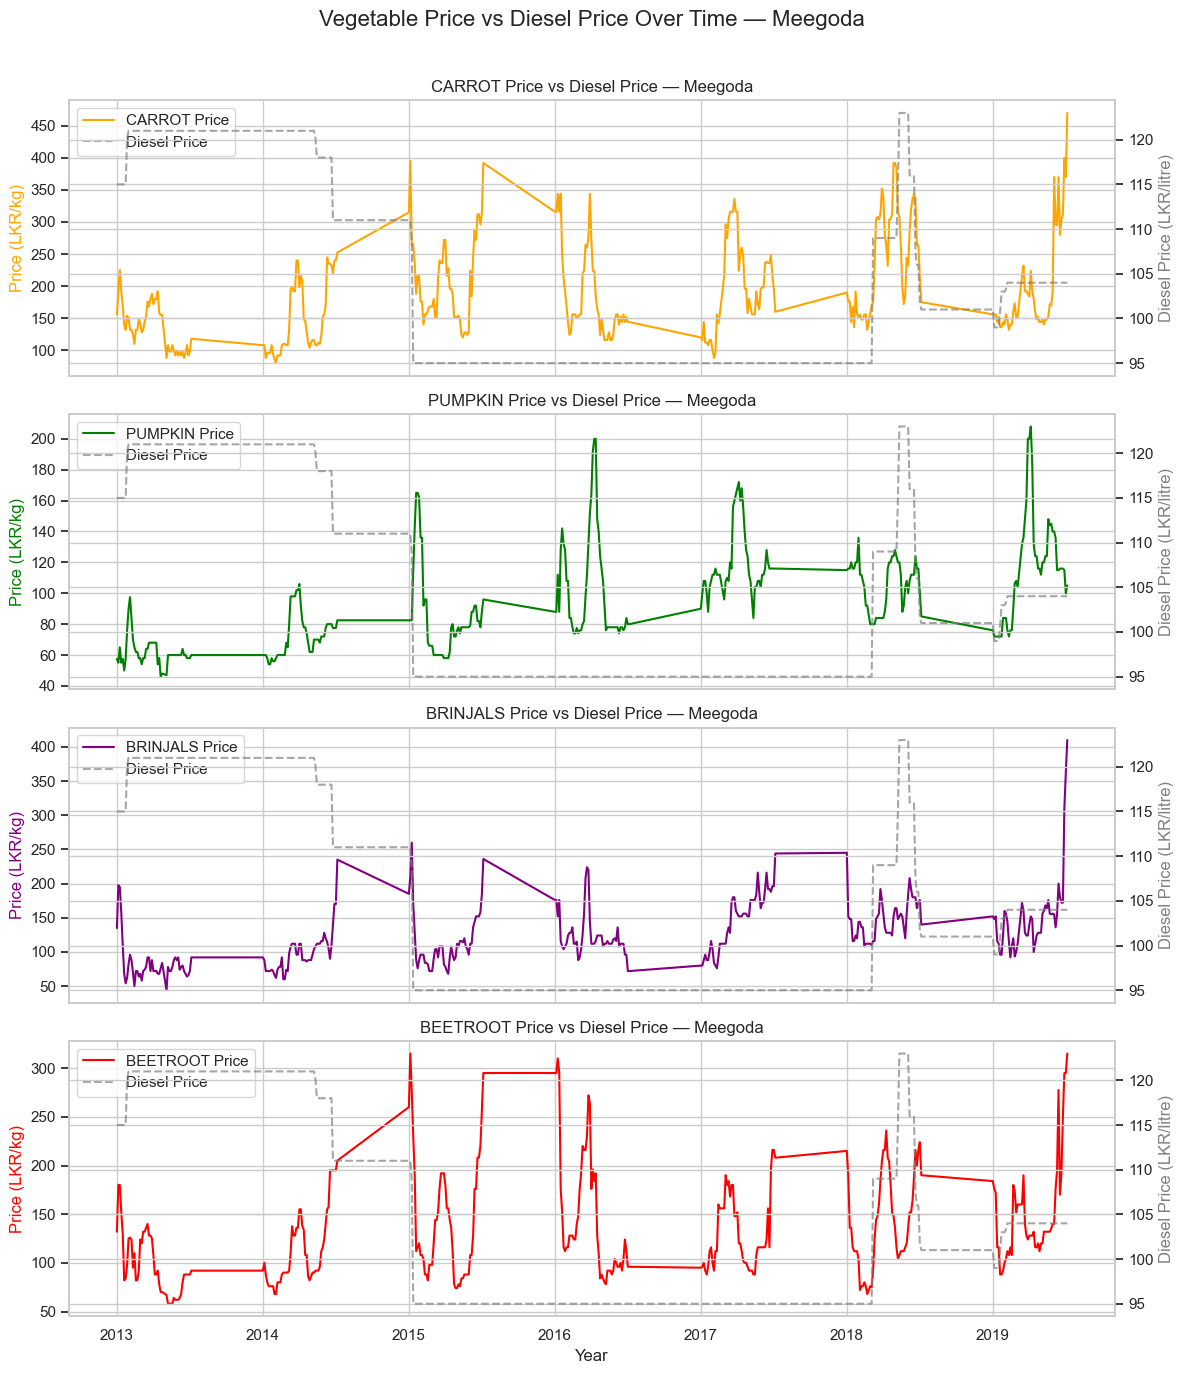

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
for i, veg in enumerate(veg_list):
    ax = axes[i]
    data = df_meegoda[df_meegoda['vegetable_type'] == veg]
    # Left y-axis: vegetable price
    l1 = ax.plot(data['time_index'], data['price'], color=veg_colors[veg], label=f'{veg} Price')
    ax.set_ylabel('Price (LKR/kg)', color=veg_colors[veg])
    # Right y-axis: diesel price
    ax2 = ax.twinx()
    l2 = ax2.plot(data['time_index'], data['lanka_auto_diesel_price'], color='grey', linestyle='--', alpha=0.7, label='Diesel Price')
    ax2.set_ylabel('Diesel Price (LKR/litre)', color='grey')
    # Title
    ax.set_title(f'{veg} Price vs Diesel Price — Meegoda')
    # Legend
    lines = l1 + l2
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper left')
    # X-ticks: first week of each year
    years = sorted(data['year'].unique())
    xticks = [y * 100 + 1 for y in years]
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(y) for y in years])
    if i < 3:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Year')
plt.suptitle('Vegetable Price vs Diesel Price Over Time — Meegoda', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('plot1_dual_axis_meegoda.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3 — Scatter Plot (diesel vs price, all 4 vegetables)
- Color by vegetable, regression line, Pearson r
- Save as plot2_scatter_meegoda.png

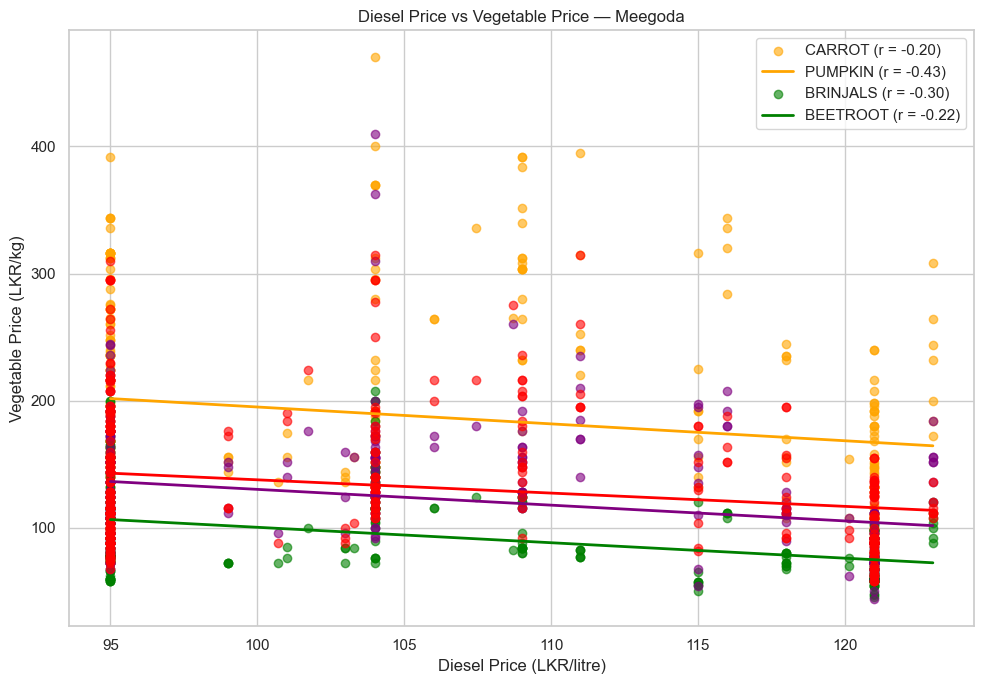

In [4]:
plt.figure(figsize=(10, 7))
legend_labels = []
for veg in veg_list:
    data = df_meegoda[df_meegoda['vegetable_type'] == veg]
    plt.scatter(data['lanka_auto_diesel_price'], data['price'], color=veg_colors[veg], alpha=0.6, label=veg)
    # Regression line
    if len(data) > 1:
        coef = np.polyfit(data['lanka_auto_diesel_price'], data['price'], 1)
        xfit = np.linspace(data['lanka_auto_diesel_price'].min(), data['lanka_auto_diesel_price'].max(), 100)
        yfit = coef[0] * xfit + coef[1]
        plt.plot(xfit, yfit, color=veg_colors[veg], linewidth=2)
        # Pearson r
        r, _ = pearsonr(data['lanka_auto_diesel_price'], data['price'])
        legend_labels.append(f'{veg} (r = {r:.2f})')
    else:
        legend_labels.append(f'{veg} (r = N/A)')
plt.xlabel('Diesel Price (LKR/litre)')
plt.ylabel('Vegetable Price (LKR/kg)')
plt.title('Diesel Price vs Vegetable Price — Meegoda')
plt.legend(legend_labels)
plt.tight_layout()
plt.savefig('plot2_scatter_meegoda.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Correlation Heatmap (Meegoda, all vegetables)
- Pivot to weekly mean price per vegetable
- Add diesel and USD columns
- Pearson correlation matrix
- Save as plot3_correlation_heatmap_meegoda.png

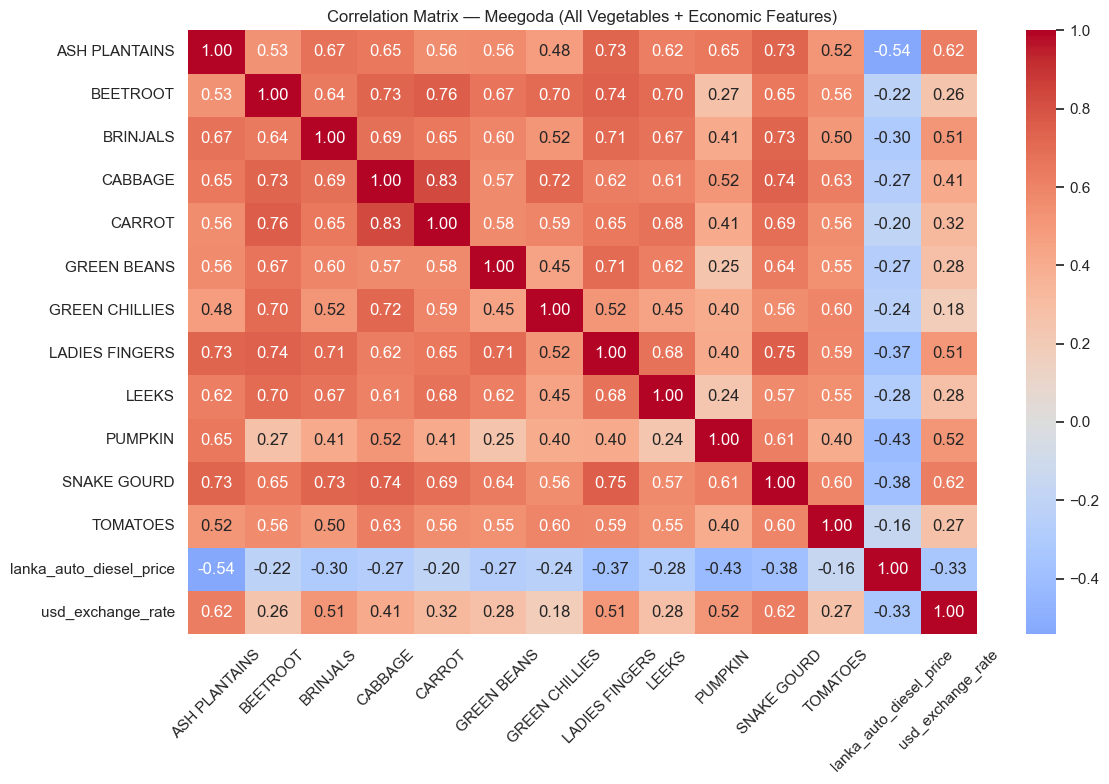

In [5]:
# Filter to Meegoda, all vegetables
df_meegoda_all = df[df['location'] == 'Meegoda'].copy()
df_meegoda_all['time_index'] = df_meegoda_all['year'] * 100 + df_meegoda_all['week_num']
# Pivot: mean price per veg per week
price_pivot = df_meegoda_all.pivot_table(index='time_index', columns='vegetable_type', values='price', aggfunc='mean')
# Add diesel and USD
diesel_usd = df_meegoda_all.groupby('time_index')[['lanka_auto_diesel_price', 'usd_exchange_rate']].mean()
corr_df = price_pivot.join(diesel_usd)
# Correlation matrix
corr = corr_df.corr(method='pearson')
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Meegoda (All Vegetables + Economic Features)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot3_correlation_heatmap_meegoda.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Dual-axis Line Chart for Colombo, Kandy, Dambulla
- Repeat Step 2 for each location
- Save as plot4_dual_axis_colombo.png, plot5_dual_axis_kandy.png, plot6_dual_axis_dambulla.png

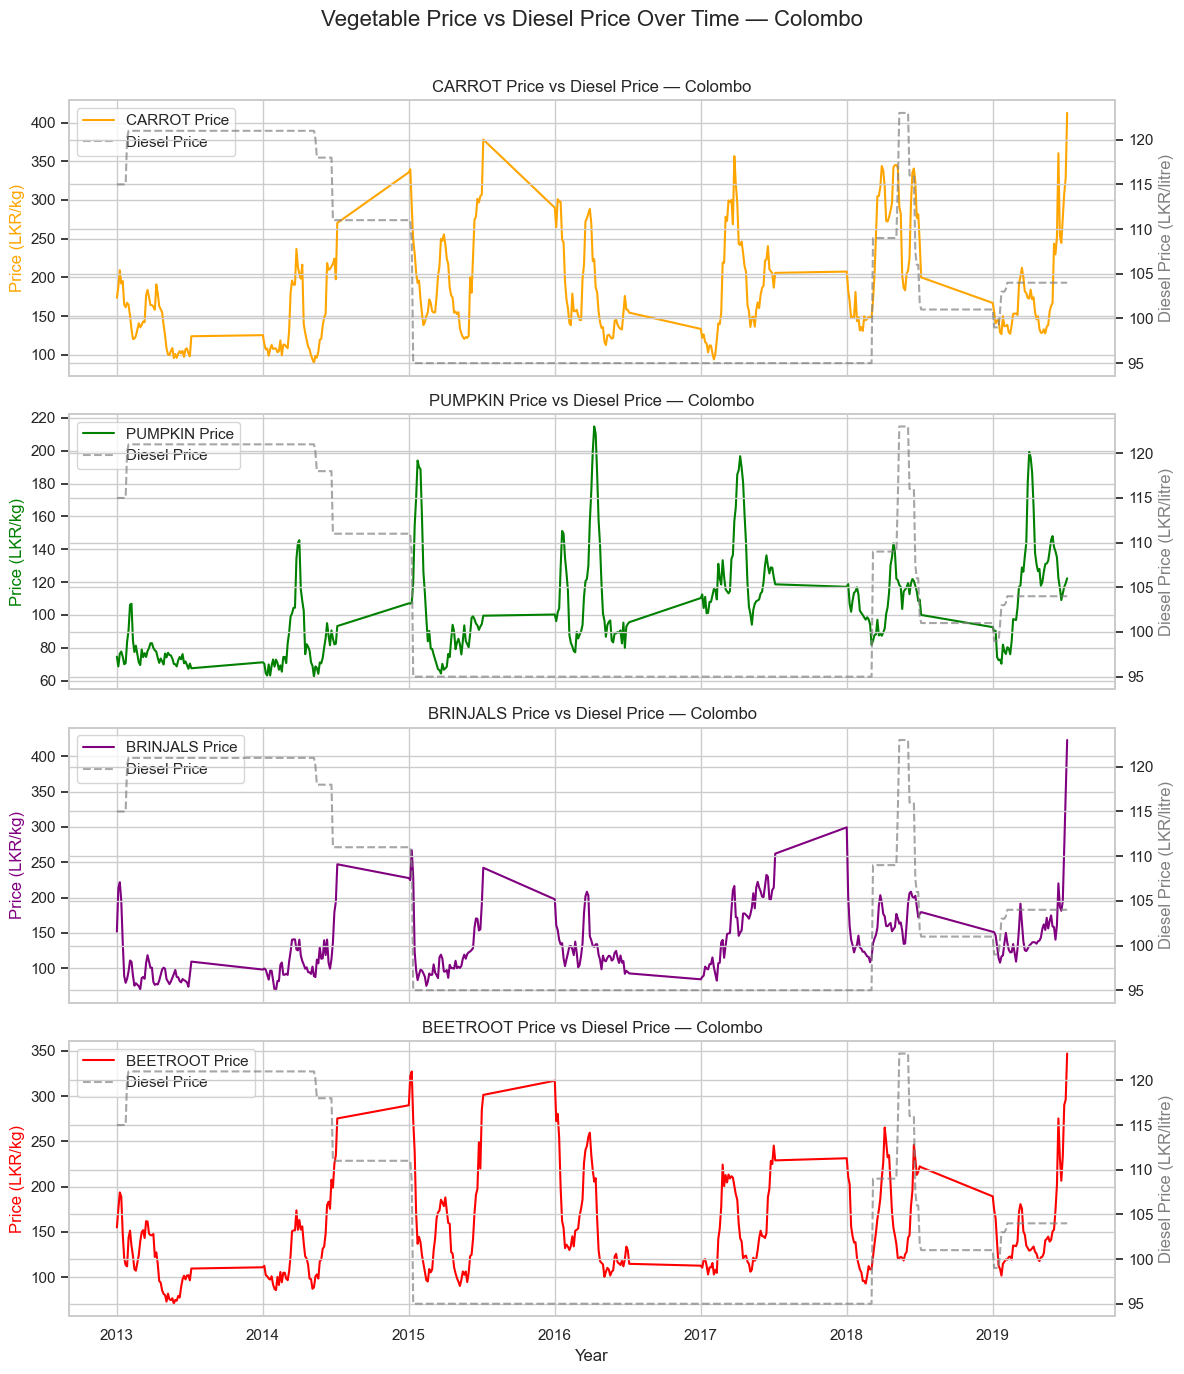

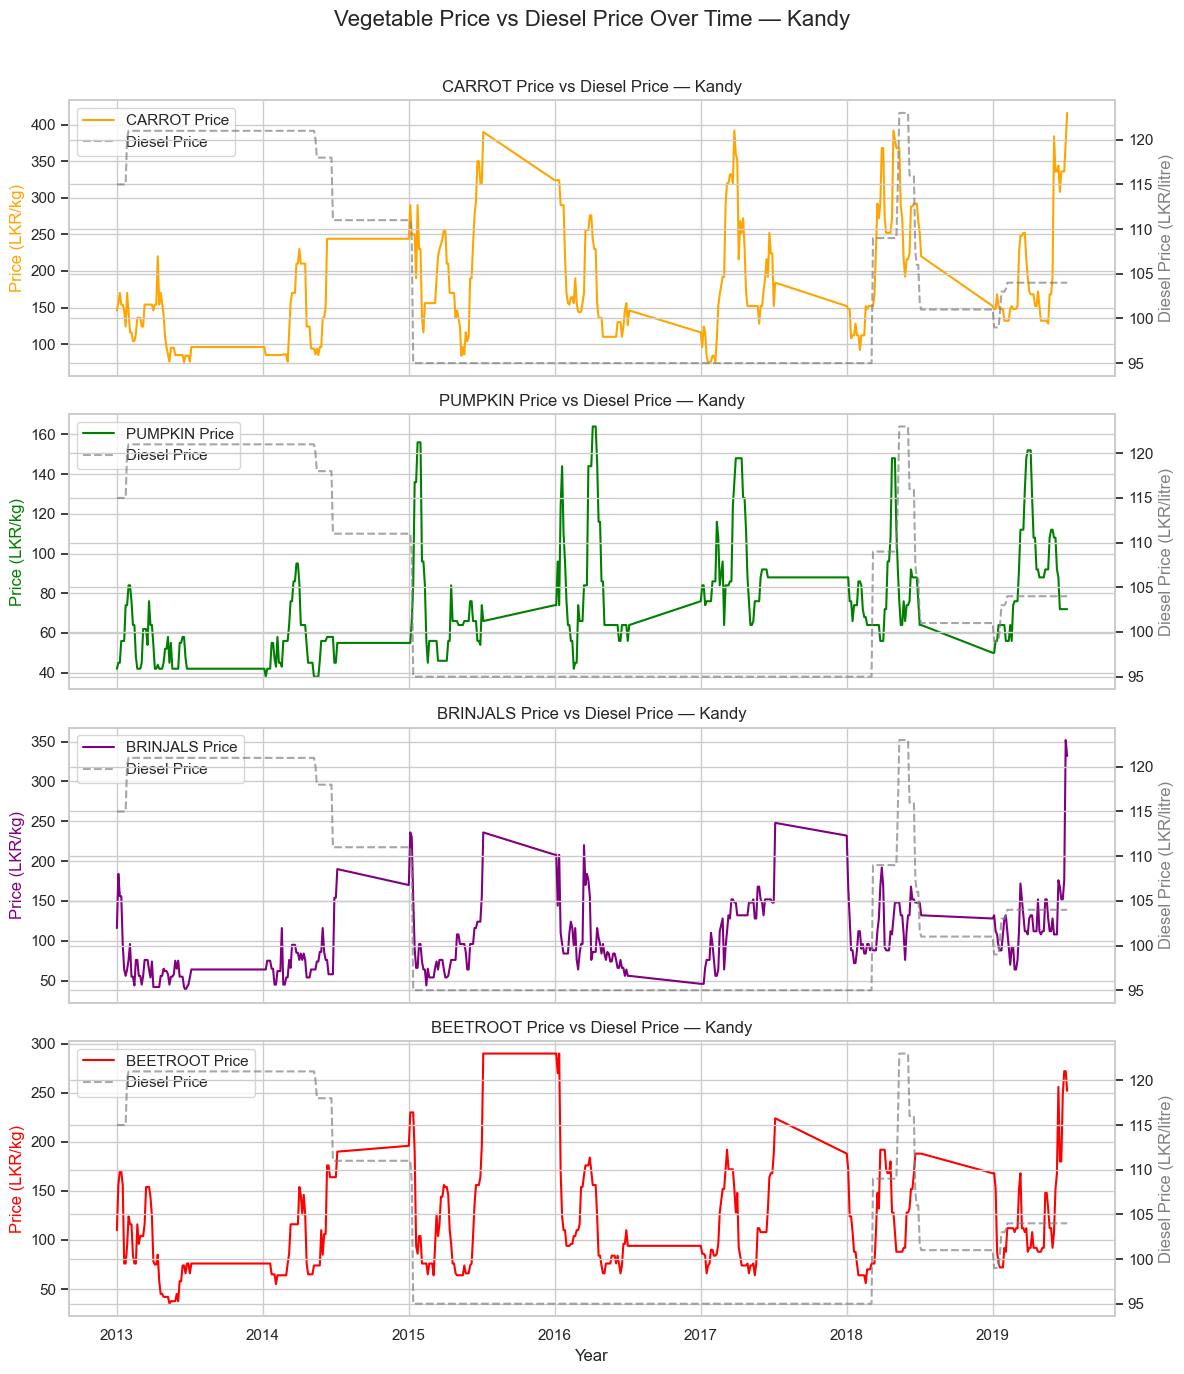

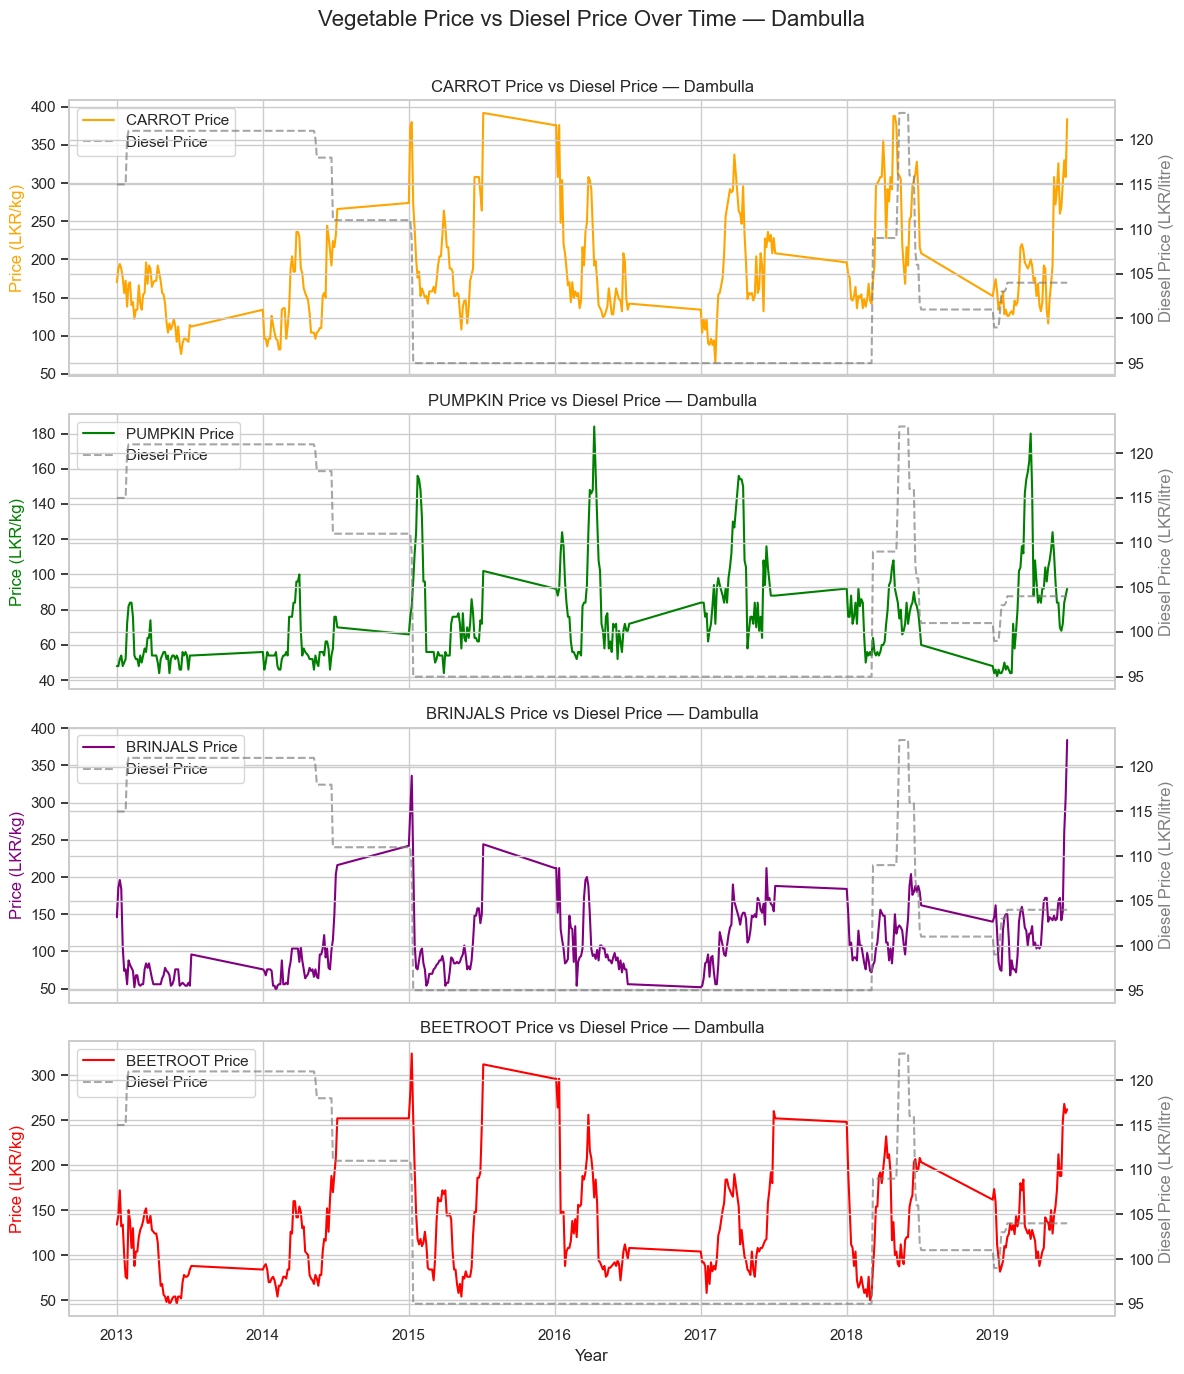

In [6]:
for loc, fname in zip(['Colombo', 'Kandy', 'Dambulla'], ['plot4_dual_axis_colombo.png', 'plot5_dual_axis_kandy.png', 'plot6_dual_axis_dambulla.png']):
    df_loc = df[(df['location'] == loc) & (df['vegetable_type'].isin(veg_list))].copy()
    df_loc['time_index'] = df_loc['year'] * 100 + df_loc['week_num']
    df_loc = df_loc.sort_values('time_index')
    df_loc = df_loc.dropna(subset=['price'])
    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
    for i, veg in enumerate(veg_list):
        ax = axes[i]
        data = df_loc[df_loc['vegetable_type'] == veg]
        l1 = ax.plot(data['time_index'], data['price'], color=veg_colors[veg], label=f'{veg} Price')
        ax.set_ylabel('Price (LKR/kg)', color=veg_colors[veg])
        ax2 = ax.twinx()
        l2 = ax2.plot(data['time_index'], data['lanka_auto_diesel_price'], color='grey', linestyle='--', alpha=0.7, label='Diesel Price')
        ax2.set_ylabel('Diesel Price (LKR/litre)', color='grey')
        ax.set_title(f'{veg} Price vs Diesel Price — {loc}')
        lines = l1 + l2
        labels = [l.get_label() for l in lines]
        ax.legend(lines, labels, loc='upper left')
        years = sorted(data['year'].unique())
        xticks = [y * 100 + 1 for y in years]
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(y) for y in years])
        if i < 3:
            ax.set_xlabel('')
        else:
            ax.set_xlabel('Year')
    plt.suptitle(f'Vegetable Price vs Diesel Price Over Time — {loc}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

## Summary: Pearson Correlation (Meegoda)
- For each vegetable, print the Pearson r and a one-line interpretation.

In [7]:
print('Pearson Correlation between Diesel Price and Vegetable Price (Meegoda):\n')
for veg in veg_list:
    data = df_meegoda[df_meegoda['vegetable_type'] == veg]
    if len(data) > 1:
        r, p = pearsonr(data['lanka_auto_diesel_price'], data['price'])
        print(f'{veg}: r = {r:.2f} (p = {p:.3g})')
        if abs(r) < 0.2:
            interp = 'No or very weak linear relationship.'
        elif abs(r) < 0.5:
            interp = 'Moderate linear relationship.'
        else:
            interp = 'Strong linear relationship.'
        print(f'  Interpretation: {interp}')
    else:
        print(f'{veg}: Not enough data.')

Pearson Correlation between Diesel Price and Vegetable Price (Meegoda):

CARROT: r = -0.20 (p = 0.000179)
  Interpretation: No or very weak linear relationship.
PUMPKIN: r = -0.43 (p = 3.91e-17)
  Interpretation: Moderate linear relationship.
BRINJALS: r = -0.30 (p = 1.01e-08)
  Interpretation: Moderate linear relationship.
BEETROOT: r = -0.22 (p = 3.28e-05)
  Interpretation: Moderate linear relationship.


# Diesel Price and Vegetable Price Analysis

This notebook analyzes the relationship between diesel prices and vegetable prices in Sri Lanka, focusing on Meegoda, Colombo, Kandy, and Dambulla.

---